# **Ejercicio 1**

/tmp/ipykernel_28021/628369228.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


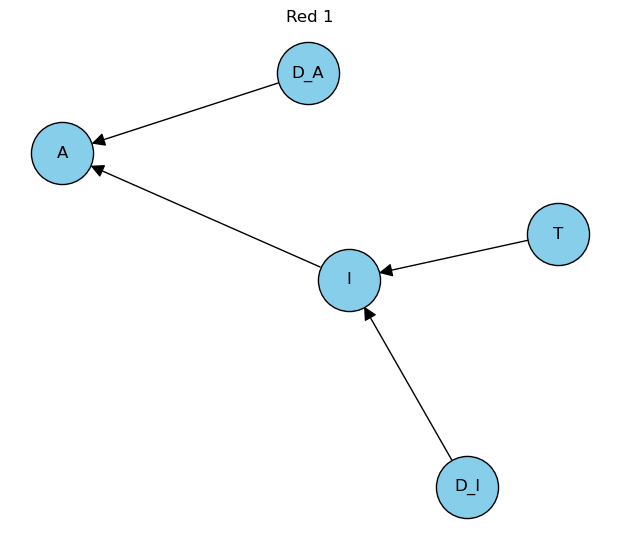

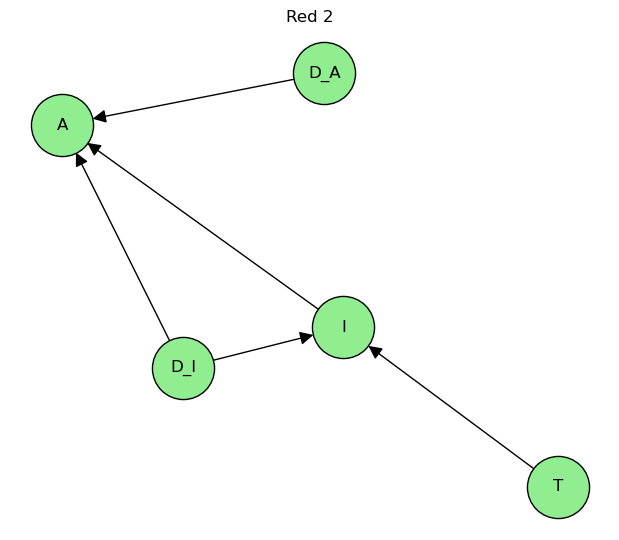

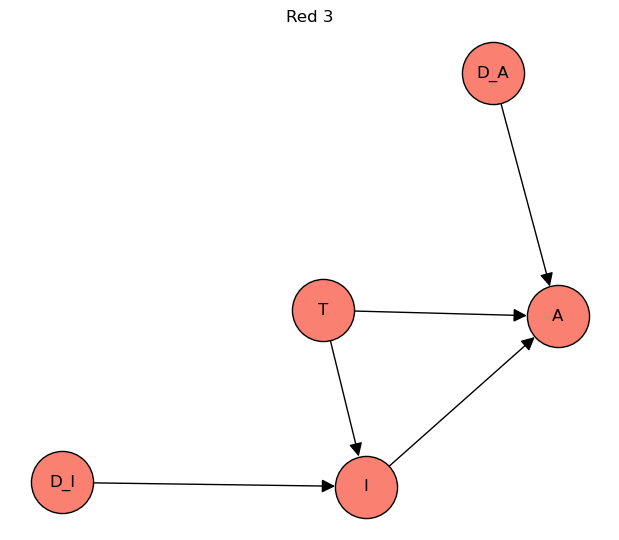

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

def dibujar_red(edges, titulo, color, nombre_archivo):
    G = nx.DiGraph()
    G.add_edges_from(edges)
    pos = nx.spring_layout(G, seed=42)
    
    plt.figure(figsize=(6, 5))
    nx.draw(
        G,
        pos,
        with_labels=True,
        node_size=2000,
        node_color=color,
        arrowsize=20,
        edgecolors='black'
    )
    plt.title(titulo)
    plt.tight_layout()
    #plt.savefig(f"{nombre_archivo}.png", dpi=300)
    plt.show()

# Red 1
edges_1 = [('T', 'I'), ('D_I', 'I'), ('I', 'A'), ('D_A', 'A')]
dibujar_red(edges_1, 'Red 1', color='skyblue', nombre_archivo='red1')

# Red 2
edges_2 = [('T', 'I'), ('D_I', 'I'), ('I', 'A'), ('D_A', 'A'), ('D_I', 'A')]
dibujar_red(edges_2, 'Red 2', color='lightgreen', nombre_archivo='red2')

# Red 3
edges_3 = [ ('T', 'A'), ('T', 'I'), ('D_I', 'I'), ('I', 'A'), ('D_A', 'A')]
dibujar_red(edges_3, 'Red 3', color='salmon', nombre_archivo='red3')

# **Ejercicio 3b)**

In [2]:
# Importamos las clases necesarias de pgmpy
from pgmpy.models import BayesianModel
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination

# 1. Definimos la estructura de la red bayesiana
# Cada tupla ('padre', 'hijo') indica una relación causal directa
model = BayesianModel([
    ('E', 'F'),  # El ébola afecta la fiebre
    ('E', 'S'),  # El ébola afecta el sangrado
    ('F', 'V'),  # La fiebre afecta la visita a la clínica
    ('S', 'V'),  # El sangrado también afecta la visita
    ('S', 'C'),  # El sangrado afecta las complicaciones
    ('V', 'D')   # La visita a la clínica afecta ser atendido por un doctor especializado
])

# 2. Definimos las distribuciones de probabilidad condicional (CPDs)

# P(E): Probabilidad marginal de tener ébola
cpd_E = TabularCPD(variable='E', variable_card=2, values=[[0.99], [0.01]])

# P(F | E): Probabilidad de fiebre dado el estado de ébola
cpd_F = TabularCPD(
    variable='F', variable_card=2, 
    values=[
        [0.4, 0.9],  # Probabilidad de NO tener fiebre
        [0.6, 0.1]   # Probabilidad de tener fiebre
    ],
    evidence=['E'],
    evidence_card=[2]
)

# P(S | E): Probabilidad de sangrado dado el estado de ébola
cpd_S = TabularCPD(
    variable='S', variable_card=2,
    values=[
        [0.2, 0.95],  # Probabilidad de NO tener sangrado
        [0.8, 0.05]   # Probabilidad de tener sangrado
    ],
    evidence=['E'],
    evidence_card=[2]
)

# P(V | F, S): Probabilidad de visitar la clínica dado fiebre y sangrado
cpd_V = TabularCPD(
    variable='V', variable_card=2,
    values=[
        [0.2, 0.5, 0.3, 1.0],  # Probabilidad de NO visitar la clínica
        [0.8, 0.5, 0.7, 0.0]   # Probabilidad de visitar la clínica
    ],
    evidence=['F', 'S'],  # Fiebre y Sangrado son los padres de Visita
    evidence_card=[2, 2]
)

# P(C | S): Probabilidad de complicaciones dado sangrado
cpd_C = TabularCPD(
    variable='C', variable_card=2,
    values=[
        [0.25, 0.9],  # Probabilidad de NO tener complicaciones
        [0.75, 0.1]   # Probabilidad de tener complicaciones
    ],
    evidence=['S'],
    evidence_card=[2]
)

# P(D | V): Probabilidad de ser visto por un doctor especializado dado la visita
cpd_D = TabularCPD(
    variable='D', variable_card=2,
    values=[
        [0.4, 1.0],  # Probabilidad de NO ser visto por un doctor
        [0.6, 0.0]   # Probabilidad de ser visto por un doctor
    ],
    evidence=['V'],
    evidence_card=[2]
)

# 3. Agregamos todas las CPDs al modelo
model.add_cpds(cpd_E, cpd_F, cpd_S, cpd_V, cpd_C, cpd_D)

# 4. Verificamos que el modelo sea válido
# (Revisa consistencia: estructura y dimensiones de las tablas)
assert model.check_model()

# 5. Definimos un objeto de inferencia basado en eliminación de variables
infer = VariableElimination(model)

# Calculamos la distribución de E dado que D = verdadero
query = infer.query(variables=['E'], evidence={'D': 1})

# Mostramos el resultado
print(query)

Eliminating: V: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 495.15it/s]

+------+----------+
| E    |   phi(E) |
+======+==========+
| E(0) |   0.9967 |
+------+----------+
| E(1) |   0.0033 |
+------+----------+


# **Ejercicio 3c)**

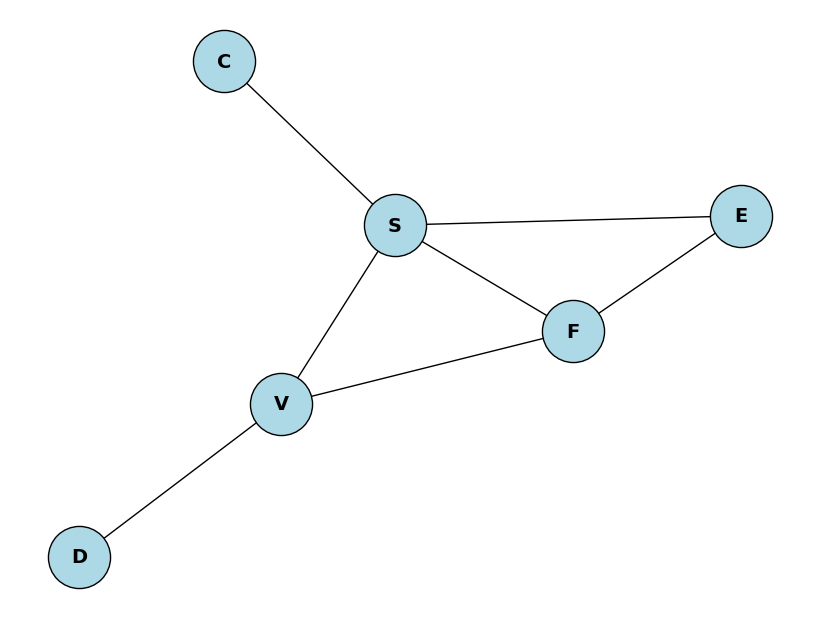

In [6]:
import networkx as nx
import matplotlib.pyplot as plt

# Crear grafo no dirigido
G = nx.Graph()

# Agregamos las conexiones después de moralizar
edges = [
    ('E', 'F'),
    ('E', 'S'),
    ('F', 'S'),  # Moralización
    ('F', 'V'),
    ('S', 'V'),
    ('S', 'C'),
    ('V', 'D')
]

G.add_edges_from(edges)

# Dibujamos el grafo
plt.figure(figsize=(8,6))
nx.draw(G,
        with_labels=True,
        node_size=2000,
        node_color='lightblue',
        font_size=14,
        font_weight='bold',
        edgecolors='black')
#plt.title("Modelo no dirigido (Campo Aleatorio de Markov)")
plt.savefig("Tarea3-3c")
plt.show()

# **Ejercicio 3e)**

In [9]:
# Realizamos una nueva consulta con el modeolo creado anteriormente:
query_e = infer.query(variables=['V'], evidence={'E': 1})

# Mostramos resultados
print(query_e)

Eliminating: D: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 418.88it/s]

+------+----------+
| V    |   phi(V) |
+======+==========+
| V(0) |   0.2270 |
+------+----------+
| V(1) |   0.7730 |
+------+----------+


# **Ejercicio 3f)**

In [10]:
# Consultar P(E | D=1, F=0)
query_f = infer.query(variables=['E'], evidence={'D': 1, 'F': 0})

# Consultar P(E | F=0)
query_only_f = infer.query(variables=['E'], evidence={'F': 0})

# Imprimimos los resultados
print("P(E | D=1, F=0):")
print(query_f)

print("\nP(E | F=0):")
print(query_only_f)

Eliminating: D: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 643.54it/s]

P(E | D=1, F=0):
+------+----------+
| E    |   phi(E) |
+======+==========+
| E(0) |   0.9890 |
+------+----------+
| E(1) |   0.0110 |
+------+----------+

P(E | F=0):
+------+----------+
| E    |   phi(E) |
+======+==========+
| E(0) |   0.9778 |
+------+----------+
| E(1) |   0.0222 |
+------+----------+
